In [1]:
from sklearn.datasets import load_breast_cancer

# Load data
data = load_breast_cancer()
X = data.data
y = data.target

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Define instantiated models (not classes) with reasonable params
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "svm": SVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost" : XGBClassifier(eval_metric="logloss", random_state=42)
}

# Containers for metrics
names = []
acc_list = []
precision_list = []
recall_list = []
f1_list = []

# Fit, predict, and collect metrics
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    names.append(name)
    acc_list.append(accuracy_score(y_test, y_pred))
    precision_list.append(precision_score(y_test, y_pred))
    recall_list.append(recall_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred))

# Assemble results into a DataFrame
final_result = pd.DataFrame({
    "Model": names,
    "Accuracy": acc_list,
    "Precision": precision_list,
    "Recall": recall_list,
    "f1": f1_list
})

print(f"Final result is: \n {final_result}")


Final result is: 
                  Model  Accuracy  Precision    Recall        f1
0  Logistic Regression  0.973684   0.972222  0.985915  0.979021
1                  svm  0.982456   0.972603  1.000000  0.986111
2        Random Forest  0.964912   0.958904  0.985915  0.972222
3              XGBoost  0.964912   0.958904  0.985915  0.972222


In [16]:
best_model = final_result.sort_values(by="f1", ascending=False).iloc[0]
print(best_model)

Model             svm
Accuracy     0.982456
Precision    0.972603
Recall            1.0
f1           0.986111
Name: 1, dtype: object


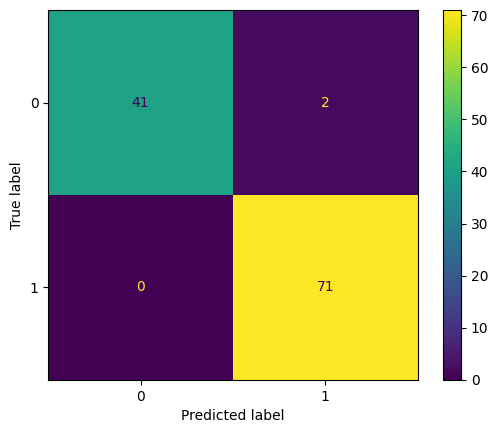

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model_pred = models[best_model["Model"]].predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, best_model_pred)

  0%|          | 0/50 [00:00<?, ?it/s]

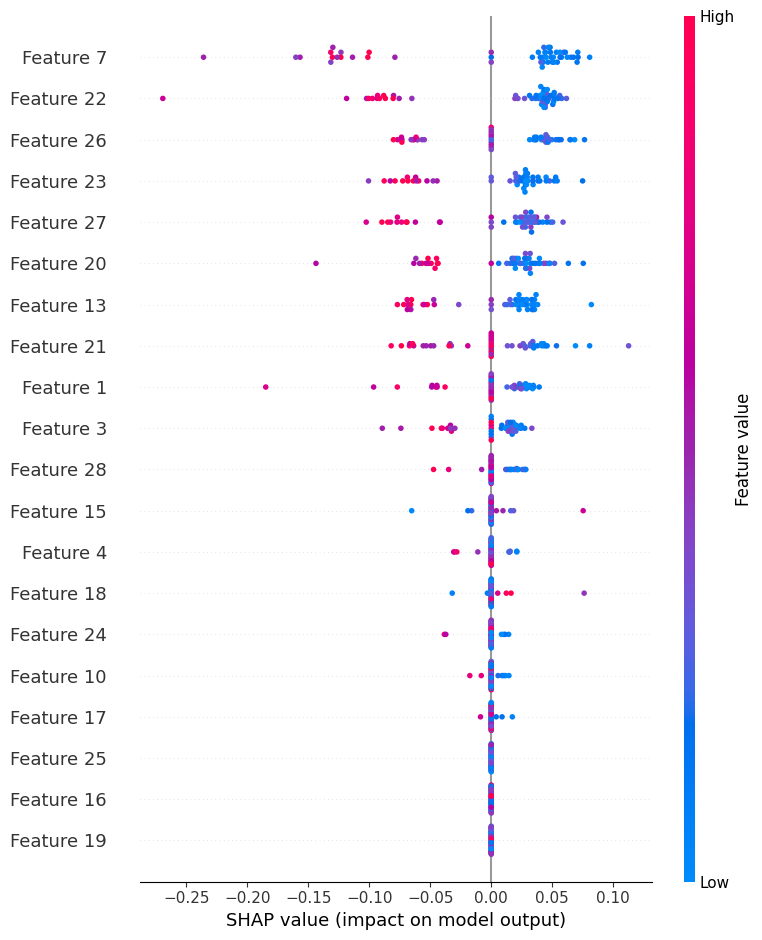

In [20]:
import shap

explainer = shap.KernelExplainer(model.predict, X_train[:100])
shap_values = explainer.shap_values(X_test[:50])
shap.summary_plot(shap_values, X_test[:50])